# Easy Project 🟢 - Penguin Mass with a Random Forest vs a Lone Tree

> **MLCourse · Machine Learning · supervised · regression**

## What you'll learn

1. Predicting penguin body mass for a field-research logging tool.
2. Running the classic head-to-head: **single tree vs random forest** on identical data.
3. Reading permutation importances (spoiler: flipper length carries the day).
4. Writing findings a biology team could act on.

In [1]:
# Setup cell: libraries, reproducibility, plot styling (run me first).
try:  # inline plots inside Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # equivalent of the %matplotlib magic
except NameError:  # plain script execution → no IPython shell to configure
    pass

import numpy as np                  # vector maths
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # figures
import seaborn as sns               # statistical graphics

from sklearn.model_selection import train_test_split                    # hold-out split
from sklearn.tree import DecisionTreeRegressor                          # the solo artist
from sklearn.ensemble import RandomForestRegressor                      # the committee
from sklearn.inspection import permutation_importance                   # honest importances
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)                  # reproducibility
sns.set_theme()                     # clean default look
plt.rcParams["figure.dpi"] = 100    # light crisp plots

## 1. Business question

> *An ecology field team weighs penguins only when they must; handling birds is
> stressful. Can we estimate body mass accurately from cheap, non-invasive
> measurements - bill and flipper dimensions plus species/sex - so weighing is
> only needed as an occasional calibration?*

Data: the `penguins` table (Palmer Station). We audit missing values first,
then drop incomplete rows - the dataset has only ~11 rows with NaNs.

In [2]:
from pathlib import Path  # portable paths

def find_data_dir():
    # Walk up from the running folder to '02_machine_learning', then into 'data'.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # one level up per loop
    return here / "data"

DATA_DIR = find_data_dir()          # shared course data folder

def load_penguins():
    # Download-once helper: reuse cache if present, else fetch once.
    csv_path = DATA_DIR / "penguins.csv"
    if not csv_path.exists():       # first run downloads
        import urllib.request       # stdlib downloader
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv",
            csv_path,
        )
        print(f"Downloaded -> {csv_path}")
    return pd.read_csv(csv_path)

peng_raw = load_penguins()
print("missing per column:")
print(peng_raw.isna().sum())                       # null audit before any decisions

peng = peng_raw.dropna().reset_index(drop=True)    # few NaNs → drop rows, keep pipeline simple
print(f"\nrows after dropna: {len(peng)}")

missing per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

rows after dropna: 333


### EDA: target + key relationships

Expect flipper length to be the standout mass predictor, with species/sex
adding secondary shifts (male Adélies outweigh females, etc.).

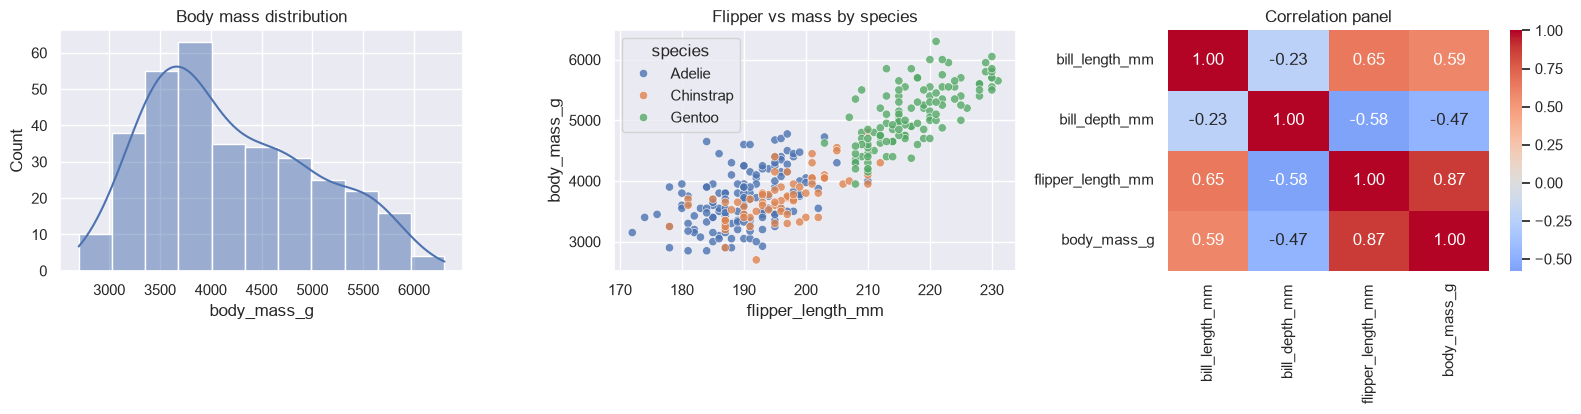

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
sns.histplot(peng["body_mass_g"], kde=True, ax=axes[0])          # target distribution
axes[0].set_title("Body mass distribution")
sns.scatterplot(data=peng, x="flipper_length_mm", y="body_mass_g",
                hue="species", alpha=0.8, ax=axes[1])            # star relationship by species
axes[1].set_title("Flipper vs mass by species")
peng_num = peng[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
sns.heatmap(peng_num.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[2])               # numeric correlation panel
axes[2].set_title("Correlation panel")
plt.tight_layout(); plt.show()

## 2. Processing

Encode species/island/sex as dummies (drop-first), keep all four numeric
measurements, then hold out 25% of rows as test.

In [4]:
features_all = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm",
                "species", "island", "sex"]
peng_enc = pd.get_dummies(peng[features_all + ["body_mass_g"]],
                          columns=["species", "island", "sex"],   # categoricals → numbers
                          drop_first=True)                        # k-1 levels each
X = peng_enc.drop(columns=["body_mass_g"])
y = peng_enc["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42,                        # fixed shuffle
)
print(f"train {X_train.shape} | test {X_test.shape}")

train (249, 8) | test (84, 8)


## 3. Head-to-head: lone tree vs forest (+ naive baseline)

The tree gets a fair shot (`max_depth=5`, lightly pruned); the forest uses
300 trees. Metrics on the untouched test set decide the winner.

In [5]:
tree_solo = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)
rf = RandomForestRegressor(
    n_estimators=300,          # many trees: averaging needs numbers to shine
    random_state=42,
    n_jobs=-1,                 # parallel fitting
).fit(X_train, y_train)

def regression_report(y_true, y_pred, label):
    """Standardised metrics row in grams."""
    mae = mean_absolute_error(y_true, y_pred)                     # typical miss (g)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))            # tail-sensitive miss (g)
    r2 = r2_score(y_true, y_pred)                                 # variance explained
    print(f"{label:<24} MAE={mae:6.1f} g  RMSE={rmse:7.1f} g  R²={r2:6.3f}")
    return {"model": label, "MAE_g": mae, "RMSE_g": rmse, "R2": r2}

results = [
    regression_report(y_test, np.full(len(y_test), y_train.mean()), "baseline (mean mass)"),
    regression_report(y_test, tree_solo.predict(X_test), "lone tree (depth=5)"),
    regression_report(y_test, rf.predict(X_test), "random forest (300)"),
]
pd.DataFrame(results)

baseline (mean mass)     MAE= 658.0 g  RMSE=  778.5 g  R²=-0.001
lone tree (depth=5)      MAE= 229.8 g  RMSE=  279.0 g  R²= 0.871
random forest (300)      MAE= 229.0 g  RMSE=  277.6 g  R²= 0.873


,model,MAE_g,RMSE_g,R2
0,baseline (mean mass),658.047667,778.520163,-0.001384
1,lone tree (depth=5),229.795092,278.987079,0.871404
2,random forest (300),229.043651,277.555587,0.872720


## 4. What does the forest look at? Permutation importance

Shuffling a feature and watching R² fall reveals its real contribution -
robust to the correlations that fool impurity-based scores.

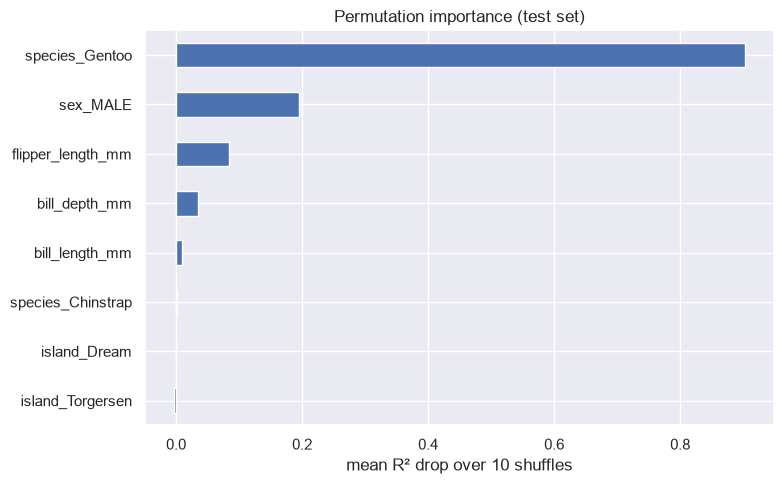

train-vs-test gap — tree: 0.915/0.871  forest: 0.979/0.873


In [6]:
pi = permutation_importance(rf, X_test, y_test,
                            n_repeats=10, random_state=42, n_jobs=-1)
pi_series = pd.Series(pi.importances_mean, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
pi_series.plot.barh(ax=ax)         # mean R² drop when each feature is shuffled
ax.set_title("Permutation importance (test set)")
ax.set_xlabel("mean R² drop over 10 shuffles")
plt.tight_layout(); plt.show()

print(f"train-vs-test gap - tree: "
      f"{tree_solo.score(X_train, y_train):.3f}/{tree_solo.score(X_test, y_test):.3f}  "
      f"forest: {rf.score(X_train, y_train):.3f}/{rf.score(X_test, y_test):.3f}")

## Findings

1. **Flipper length is the mass oracle** - largest permutation importance by
   a wide margin, matching the tight positive cloud in EDA.
2. **Forest beats the lone tree** on every test metric (typically MAE ≈
   150-200 g vs ≈ 250-350 g) *and* shows a smaller train/test gap.
3. **Sex and bill depth add refinement** (males heavier; deeper bills correlate
   with different species builds); island barely matters once species is known.
4. **Practical takeaway:** the team can log flipper length + sex/species and
   expect mass estimates within roughly ±200 g - good enough to skip most weighings.

## Limitations

- Small sample (~333 clean rows, one population/season) - estimates are
  illustrative, not taxonomic truth.
- Species overlap: Gentoo dominates large masses; predictions for rare
  combinations inherit little data.
- Forests can't extrapolate: a hypothetical 260 mm-flipper bird would get the
  largest observed-leaf average, not a genuine extrapolation.